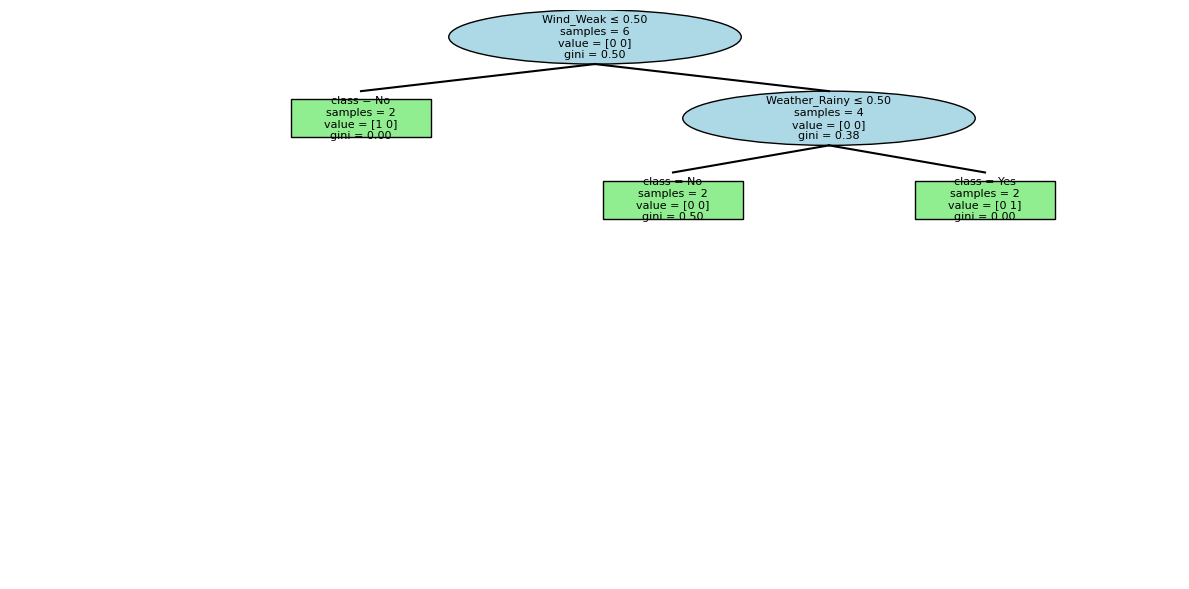

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
data = {
   'Weather': ['Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Sunny'],
   'Wind': ['Weak', 'Strong', 'Weak', 'Strong', 'Weak', 'Weak'],
   'Play': ['No', 'No', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)
X = pd.get_dummies(df[['Weather', 'Wind']])
y = df['Play']
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(X, y)
tree = model.tree_
feature_names = X.columns
class_names = model.classes_
def draw_tree(ax, node_id=0, x=0.5, y=1.0, dx=0.2, dy=0.15):
   left = tree.children_left[node_id]
   right = tree.children_right[node_id]
   is_leaf = left == _tree.TREE_LEAF
   impurity = tree.impurity[node_id]
   n_samples = tree.n_node_samples[node_id]
   values = tree.value[node_id][0]
   predicted_class = class_names[values.argmax()]
   value_str = str(values.astype(int))
   if is_leaf:
       label = f"class = {predicted_class}\nsamples = {n_samples}\nvalue = {value_str}\ngini = {impurity:.2f}"
       rect = Rectangle((x-0.06, y-0.035), 0.12, 0.07, facecolor='lightgreen', edgecolor='black')
       ax.add_patch(rect)
       ax.text(x, y, label, ha='center', va='center', fontsize=8)
   else:
       feature = feature_names[tree.feature[node_id]]
       threshold = tree.threshold[node_id]
       label = f"{feature} ≤ {threshold:.2f}\nsamples = {n_samples}\nvalue = {value_str}\ngini = {impurity:.2f}"
       ellipse = Ellipse((x, y), 0.25, 0.1, facecolor='lightblue', edgecolor='black')
       ax.add_patch(ellipse)
       ax.text(x, y, label, ha='center', va='center', fontsize=8)
       new_y = y - dy
       draw_tree(ax, left, x - dx, new_y, dx/1.5, dy)
       draw_tree(ax, right, x + dx, new_y, dx/1.5, dy)
       ax.plot([x, x - dx], [y - 0.05, new_y + 0.05], 'k-')
       ax.plot([x, x + dx], [y - 0.05, new_y + 0.05], 'k-')
fig, ax = plt.subplots(figsize=(12, 6))
draw_tree(ax)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.axis('off')
plt.tight_layout()
plt.show()